In [32]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision.models as models
import torchvision.transforms as transforms
import torchvision.transforms.functional as F
import os, shutil, sys
import random
import glob
import xml.etree.ElementTree as ET
import cv2
import pandas as pd
import time
import contextlib
from PIL import Image

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# DATA VISUALISATION

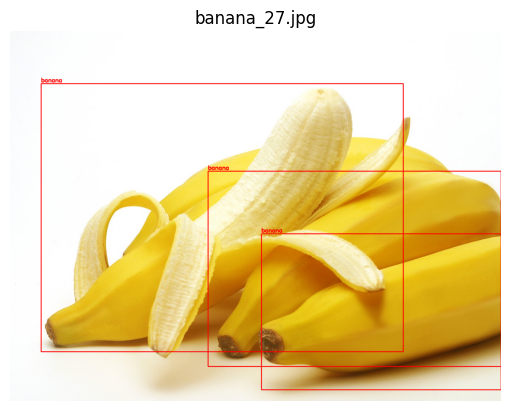

In [16]:
train_dir = "train_zip"
img_path = random.choice(glob.glob(os.path.join(train_dir, "**", "*.jpg"), recursive=True))
xml_path = img_path.replace(".jpg", ".xml")

# Parse bounding boxes from XML
boxes = []
for obj in ET.parse(xml_path).getroot().findall("object"):
    b = obj.find("bndbox")
    boxes.append((
        obj.find("name").text,
        int(float(b.find("xmin").text)), int(float(b.find("ymin").text)),
        int(float(b.find("xmax").text)), int(float(b.find("ymax").text))
    ))

image = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
for label, xmin, ymin, xmax, ymax in boxes:
    cv2.rectangle(image, (xmin, ymin), (xmax, ymax), (255, 0, 0), 2)
    cv2.putText(image, label, (xmin, ymin - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

plt.imshow(image)
plt.title(os.path.basename(img_path))
plt.axis("off")
plt.show()

# TASK 1

In [17]:
def iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    intersection = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])

    return intersection / (area1 + area2 - intersection)

# Highly overlapping
print(iou([0, 0, 10, 10], [1, 1, 9, 9]))   

# Partially overlapping
print(iou([0, 0, 10, 10], [5, 5, 15, 15])) 

# Disjoint
print(iou([0, 0, 10, 10], [20, 20, 30, 30])) 

0.64
0.14285714285714285
0.0


# TASK 2

Note -: Selective Search is in the opencv-contrib package

(np.float64(-0.5), np.float64(1599.5), np.float64(1204.5), np.float64(-0.5))

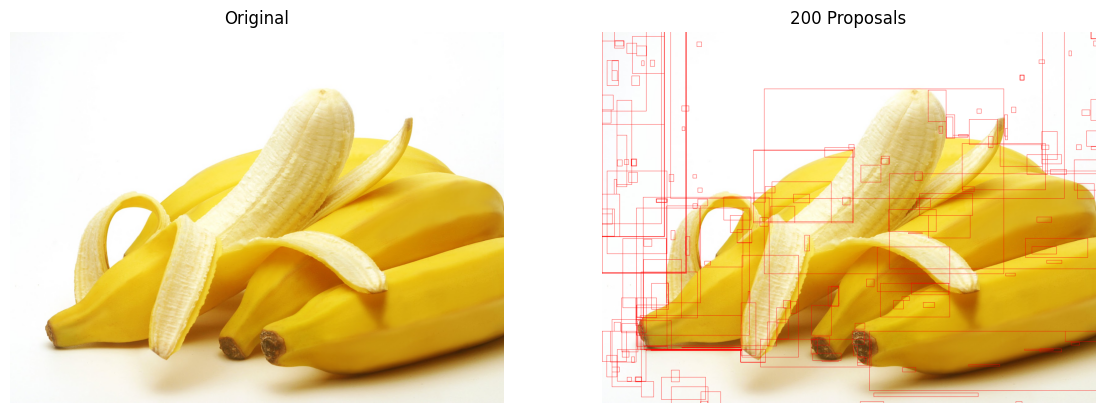

In [18]:
image = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)

ss = cv2.ximgproc.segmentation.createSelectiveSearchSegmentation()
ss.setBaseImage(cv2.imread(img_path))
ss.switchToSelectiveSearchFast()
proposals = ss.process()[:200]

canvas = image.copy()
for x, y, w, h in proposals:
    cv2.rectangle(canvas, (x, y), (x+w, y+h), (255, 0, 0), 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
ax1.imshow(image);  ax1.set_title("Original")
ax1.axis("off")

ax2.imshow(canvas); ax2.set_title("200 Proposals")
ax2.axis("off")

# TASK 3

In [19]:
model = models.resnet18(pretrained=True)
model.fc = torch.nn.Identity()
model.eval()

preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

features = []
start = time.time()

for x, y, w, h in proposals[:100]:
    crop = Image.fromarray(image[y:y+h, x:x+w])
    tensor = preprocess(crop).unsqueeze(0)
    with torch.no_grad():
        feat = model(tensor)
    features.append(feat)

bottleneck_time = time.time() - start
print(f"Time for 100 crops: {bottleneck_time:.2f}s")

/home/tanmay/Work/IT549/IT549_Labs/.venv-1/lib/python3.14/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/tanmay/Work/IT549/IT549_Labs/.venv-1/lib/python3.14/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Time for 100 crops: 2.06s


# TASK 4

In [20]:
from torchvision.ops import roi_pool
model = torch.nn.Sequential(*list(model.children())[:-2])
model.eval()

img_tensor = preprocess(Image.fromarray(image)).unsqueeze(0)

start = time.time()

with torch.no_grad():
    feature_map = model(img_tensor)

spatial_scale = feature_map.shape[-1] / img_tensor.shape[-1]
boxes_xyxy = torch.tensor(
    [[0, x, y, x+w, y+h] for x, y, w, h in proposals[:100]],
    dtype=torch.float32
)

roi_features = roi_pool(feature_map, boxes_xyxy, output_size=(7, 7), spatial_scale=spatial_scale)

roi_pool_time = time.time() - start 
print(f"Time for Fast R-CNN (1 pass + RoI pool): {roi_pool_time}s")

Time for Fast R-CNN (1 pass + RoI pool): 0.029459714889526367s


In [21]:
print(f"Percentage difference in time: {(bottleneck_time - roi_pool_time) / bottleneck_time * 100:.2f}%")

Percentage difference in time: 98.57%


R-CNN uses a forward pass of resnet 18 model 100 times here for each crop. Fast R-CNN just uses 1 feature map from the image and applies it to all crops by ROI pooling.

Percentage difference is hence around 99 % with some removed for pooling.

# TASK 5

/home/tanmay/Work/IT549/IT549_Labs/.venv-1/lib/python3.14/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


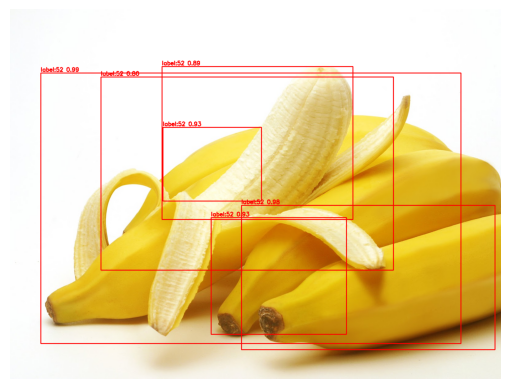

In [22]:
from torchvision.models.detection import fasterrcnn_resnet50_fpn

detector = fasterrcnn_resnet50_fpn(pretrained=True)
detector.eval()

img_tensor = transforms.ToTensor()(Image.fromarray(image))

with torch.no_grad():
    output = detector([img_tensor])[0]

def filter_predictions(output):     
    keep = output["scores"] >= 0.80
    return output["boxes"][keep], output["labels"][keep], output["scores"][keep]

boxes, labels, scores = filter_predictions(output)

canvas = image.copy()
for box, label, score in zip(boxes, labels, scores):
    x1, y1, x2, y2 = map(int, box)
    text = f"label:{label.item()} {score:.2f}"
    cv2.rectangle(canvas, (x1, y1), (x2, y2), (255, 0, 0), 2)
    cv2.putText(canvas, text, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

plt.imshow(canvas)
plt.axis("off")
plt.show()

RPN (Region Proposal Network) is a feature map in Faster R-CNN that detects region containing objects. It runs in same pass as R-CNN and is faster than external algorithms like selective search.

# TASK 6

Before NMS: 6 boxes
After NMS with threshold 0.5: 6 boxes
After NMS with threshold 0.9: 6 boxes
After NMS with threshold 0.1: 2 boxes


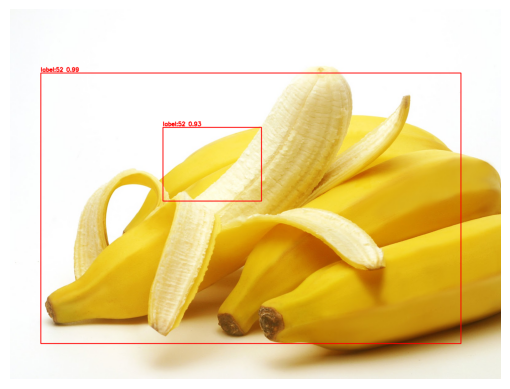

In [23]:
def nms(boxes, scores, iou_threshold=0.5):
    indices = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)
    kept = []

    while indices:
        best = indices.pop(0)
        kept.append(best)
        indices = [i for i in indices if iou(boxes[best], boxes[i]) < iou_threshold]

    return kept

# Test with Faster R-CNN output from Task 5
boxes_list  = boxes.tolist()
scores_list = scores.tolist()

kept_indices_50 = nms(boxes_list, scores_list, iou_threshold=0.5)
kept_indices_90 = nms(boxes_list, scores_list, iou_threshold=0.9)
kept_indices_10 = nms(boxes_list, scores_list, iou_threshold=0.1)
print(f"Before NMS: {len(boxes_list)} boxes")
print(f"After NMS with threshold 0.5: {len(kept_indices_50)} boxes")
print(f"After NMS with threshold 0.9: {len(kept_indices_90)} boxes")
print(f"After NMS with threshold 0.1: {len(kept_indices_10)} boxes")

# Visualize NMS results for threshold 0.1
canvas = image.copy()
for idx in kept_indices_10:
    box = boxes[idx]
    label = labels[idx]
    score = scores[idx]
    x1, y1, x2, y2 = map(int, box)
    text = f"label:{label.item()} {score:.2f}"
    cv2.rectangle(canvas, (x1, y1), (x2, y2), (255, 0, 0), 2)
    cv2.putText(canvas, text, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)
plt.imshow(canvas)
plt.axis("off")
plt.show()

As we can see, in 0.1 threshold, 2 out of 6 boxes are kept and in 0.9 and 0.5, all are kept. If a box has more Area of Intersection/ Area of Union than IOU Threshold ratio with the most likely box, it is removed. Therefore, lower threshold is more aggressive with its removal.

# TASK 7

In [16]:
base_dir  = "/home/tanmay/Work/IT549/IT549_Labs/Lab_4"
train_dir = os.path.join(base_dir, "train_zip/train")
test_dir  = os.path.join(base_dir, "test_zip/test")

# Output folders
for split in ["train", "val", "test"]:
    os.makedirs(os.path.join(base_dir, "dataset", split, "images"), exist_ok=True)
    os.makedirs(os.path.join(base_dir, "dataset", split, "labels"), exist_ok=True)

# Build class list
all_classes = sorted(set(
    obj.find("name").text
    for xml in glob.glob(os.path.join(train_dir, "*.xml"))
    for obj in ET.parse(xml).getroot().findall("object")
))
print("Classes:", all_classes)

def convert_and_copy(xml_path, img_path, split):
    root = ET.parse(xml_path).getroot()
    w = int(root.find("size/width").text)
    h = int(root.find("size/height").text)

    if w == 0 or h == 0:
        actual = cv2.imread(img_path)
        h, w = actual.shape[:2]

    lines = []
    for obj in root.findall("object"):
        cls = all_classes.index(obj.find("name").text)
        b = obj.find("bndbox")
        xmin, ymin = int(b.find("xmin").text), int(b.find("ymin").text)
        xmax, ymax = int(b.find("xmax").text), int(b.find("ymax").text)
        cx, cy = ((xmin+xmax)/2)/w, ((ymin+ymax)/2)/h
        bw, bh  = (xmax-xmin)/w,    (ymax-ymin)/h
        lines.append(f"{cls} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}")

    name = os.path.splitext(os.path.basename(img_path))[0]
    shutil.copy(img_path, os.path.join(base_dir, "dataset", split, "images", os.path.basename(img_path)))
    open(os.path.join(base_dir, "dataset", split, "labels", name + ".txt"), "w").write("\n".join(lines))

# Split train/val (80/20)
all_imgs = sorted(glob.glob(os.path.join(train_dir, "*.jpg")))
random.shuffle(all_imgs)
split_idx = int(0.8 * len(all_imgs))
train_imgs, val_imgs = all_imgs[:split_idx], all_imgs[split_idx:]

for img in train_imgs:
    convert_and_copy(img.replace(".jpg", ".xml"), img, "train")
for img in val_imgs:
    convert_and_copy(img.replace(".jpg", ".xml"), img, "val")

# Test set
for img in glob.glob(os.path.join(test_dir, "*.jpg")):
    xml = img.replace(".jpg", ".xml")
    if os.path.exists(xml):
        convert_and_copy(xml, img, "test")

# Write data.yaml
yaml = f"""train: {base_dir}/dataset/train/images
val:   {base_dir}/dataset/val/images
test:  {base_dir}/dataset/test/images
nc:    {len(all_classes)}
names: {all_classes}
"""
open(os.path.join(base_dir, "dataset", "data.yaml"), "w").write(yaml)
print(yaml)
print(f"Train: {len(train_imgs)}  Val: {len(val_imgs)}  Test: {len(glob.glob(os.path.join(test_dir, '*.jpg')))}")

Classes: ['apple', 'banana', 'orange']
train: /home/tanmay/Work/IT549/IT549_Labs/Lab_4/dataset/train/images
val:   /home/tanmay/Work/IT549/IT549_Labs/Lab_4/dataset/val/images
test:  /home/tanmay/Work/IT549/IT549_Labs/Lab_4/dataset/test/images
nc:    3
names: ['apple', 'banana', 'orange']

Train: 192  Val: 48  Test: 60


In [17]:
yaml_content = f"""train: {train_dir}
val:   {train_dir}
nc:    {len(all_classes)}
names: {all_classes}
"""
open("/home/tanmay/Work/IT549/IT549_Labs/Lab_4/train_zip/data.yaml", "w").write(yaml_content)
print(yaml_content)

train: /home/tanmay/Work/IT549/IT549_Labs/Lab_4/train_zip/train
val:   /home/tanmay/Work/IT549/IT549_Labs/Lab_4/train_zip/train
nc:    3
names: ['apple', 'banana', 'orange']



In [1]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="/home/tanmay/Work/IT549/IT549_Labs/Lab_4/dataset/data.yaml",
    epochs=10,
    batch=16,
    imgsz=640,
    project="yolo_finetune"
)

Ultralytics 8.4.33 🚀 Python-3.14.3 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 5806MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/tanmay/Work/IT549/IT549_Labs/Lab_4/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train8, nbs=64, nms=False, opset=None, optimize=False, op

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f594416d130>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

Ultralytics 8.4.33 🚀 Python-3.14.3 torch-2.10.0+cu128 CPU (13th Gen Intel Core i5-13420H)


Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2062.4±1350.4 MB/s, size: 56.2 KB)
val: Scanning /home/tanmay/Work/IT549/IT549_Labs/Lab_4/dataset/val/labels.cache... 118 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 118/118 61.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 30/30 9.6it/s 3.1s0.1s
                   all        118        218      0.903      0.881      0.935      0.704
                 apple         40         58      0.933      0.964      0.978      0.817
                banana         51         98      0.873      0.745      0.855       0.54
                orange         43         62      0.903      0.935      0.973      0.756
Speed: 0.1ms preprocess, 18.5ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to /home/tanmay/Work/IT549/IT549_Labs/Lab_4/runs/detect/val8
mAP@50    : 0.935
mAP@50-95 

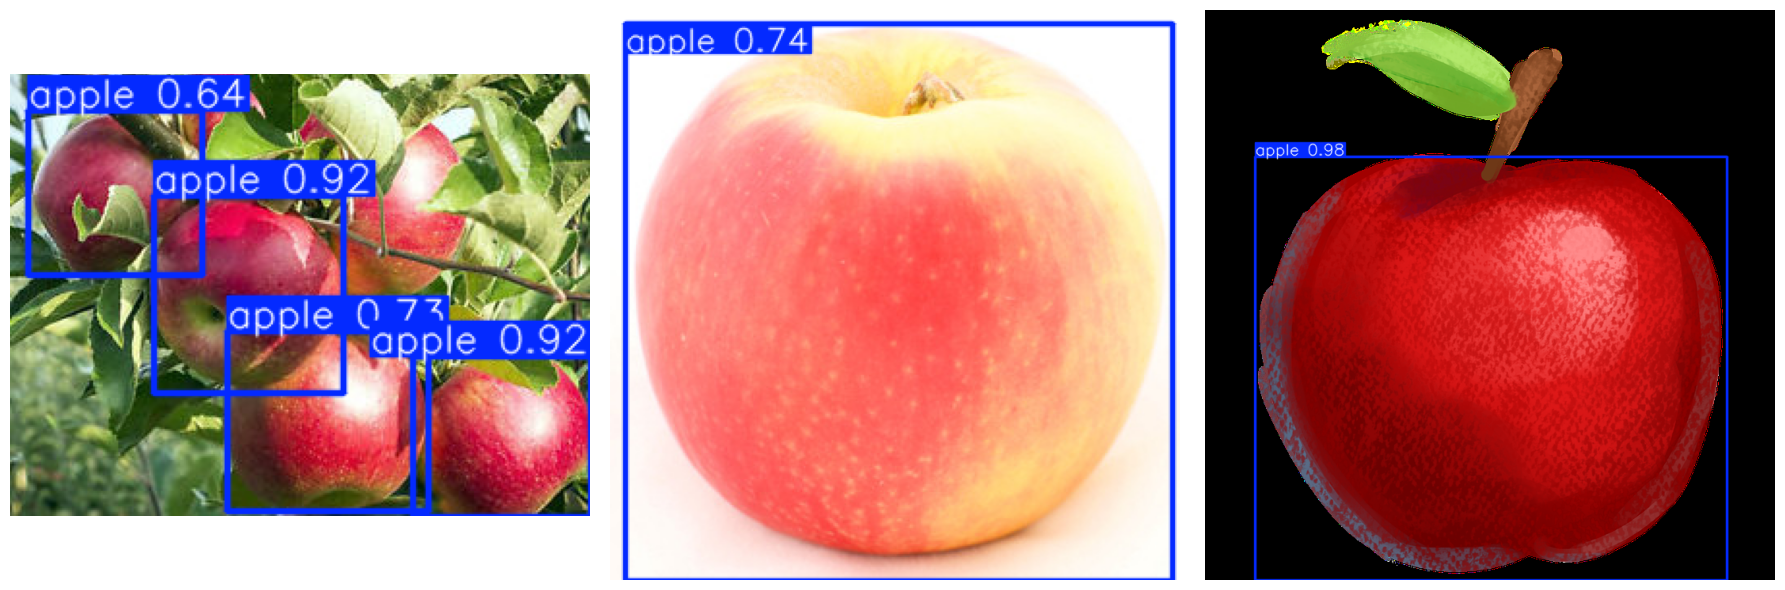

In [7]:
%matplotlib inline

finetuned = YOLO("/home/tanmay/Work/IT549/IT549_Labs/Lab_4/runs/detect/yolo_finetune/train7/weights/best.pt")

data_yaml = "/home/tanmay/Work/IT549/IT549_Labs/Lab_4/dataset/data.yaml"

metrics = finetuned.val(
    data=data_yaml,
    imgsz=416,
    batch=4,
    device="cpu"
)

print(f"mAP@50    : {metrics.box.map50:.3f}")
print(f"mAP@50-95 : {metrics.box.map:.3f}")

test_images = glob.glob(
    "/home/tanmay/Work/IT549/IT549_Labs/Lab_4/dataset/test/images/*.jpg"
)[:3]

results = finetuned(test_images, imgsz=416, device="cpu")

print("Results:", len(results))

fig, axes = plt.subplots(1, len(results), figsize=(18, 6))

if len(results) == 1:
    axes = [axes]

for ax, r in zip(axes, results):
    ax.imshow(r.plot()[:, :, ::-1])
    ax.axis("off")

plt.tight_layout()
plt.show()

Ultralytics 8.4.33 🚀 Python-3.14.3 torch-2.10.0+cu128 CPU (13th Gen Intel Core i5-13420H)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3290.3±1963.7 MB/s, size: 139.1 KB)
                   all        118        218      0.177     0.0673     0.0929      0.046
Speed: 0.7ms preprocess, 50.2ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to /home/tanmay/Work/IT549/IT549_Labs/Lab_4/runs/detect/val14
Ultralytics 8.4.33 🚀 Python-3.14.3 torch-2.10.0+cu128 CPU (13th Gen Intel Core i5-13420H)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4600.6±1629.1 MB/s, size: 91.5 KB)
                   all        118        218      0.936      0.896      0.951      0.715
Speed: 1.1ms preprocess, 71.0ms inference, 0.0ms loss, 6.8ms postprocess per image
Results saved to /home/tanmay/Work/IT549/IT549_Labs/Lab_4/runs/detect/val15


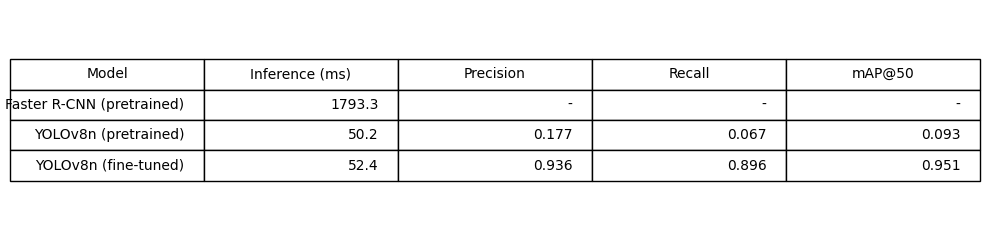


image 1/1 /home/tanmay/Work/IT549/IT549_Labs/Lab_4/dataset/test/images/apple_77.jpg: 512x640 4 apples, 133.4ms
Speed: 1.9ms preprocess, 133.4ms inference, 2.1ms postprocess per image at shape (1, 3, 512, 640)


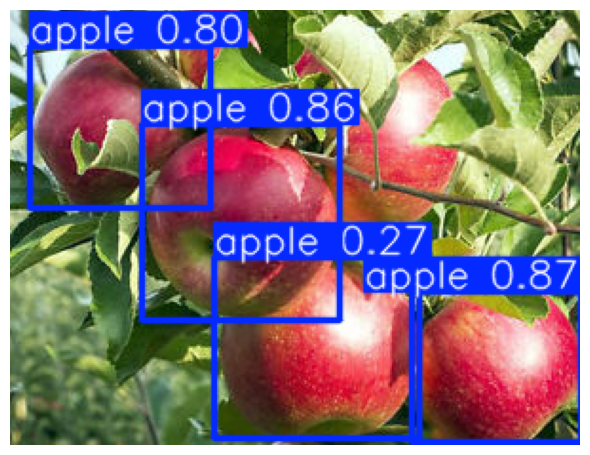

In [35]:
data_yaml = "/home/tanmay/Work/IT549/IT549_Labs/Lab_4/dataset/data.yaml"

@contextlib.contextmanager
def suppress():
    with open(os.devnull, "w") as fnull:
        old_stdout, old_stderr = sys.stdout, sys.stderr
        sys.stdout, sys.stderr = fnull, fnull
        try:
            yield
        finally:
            sys.stdout, sys.stderr = old_stdout, old_stderr

pretrained_yolo = YOLO("yolov8n.pt")
finetuned = YOLO("/home/tanmay/Work/IT549/IT549_Labs/Lab_4/runs/detect/yolo_finetune/train7/weights/best.pt")

detector = fasterrcnn_resnet50_fpn(pretrained=True)
detector.eval()

image = Image.open(img_path).convert("RGB")
img_tensor = F.to_tensor(image)

def avg_time(fn, runs=10):
    times = []
    for _ in range(runs):
        t = time.time()
        fn()
        times.append(time.time() - t)
    return (sum(times) / len(times)) * 1000

frcnn_time = avg_time(lambda: detector([img_tensor]))
yolo_pre_time = avg_time(lambda: pretrained_yolo(img_path, verbose=False))
yolo_ft_time  = avg_time(lambda: finetuned(img_path, verbose=False))

with suppress():
    yolo_pre_metrics = pretrained_yolo.val(data=data_yaml, device="cpu", verbose=False)
    yolo_ft_metrics  = finetuned.val(data=data_yaml, device="cpu", verbose=False)

df = pd.DataFrame([
    ["Faster R-CNN (pretrained)", f"{frcnn_time:.1f}", "-", "-", "-"],
    ["YOLOv8n (pretrained)",      f"{yolo_pre_time:.1f}", f"{yolo_pre_metrics.box.mp:.3f}", f"{yolo_pre_metrics.box.mr:.3f}", f"{yolo_pre_metrics.box.map50:.3f}"],
    ["YOLOv8n (fine-tuned)",      f"{yolo_ft_time:.1f}",  f"{yolo_ft_metrics.box.mp:.3f}",  f"{yolo_ft_metrics.box.mr:.3f}",  f"{yolo_ft_metrics.box.map50:.3f}"],
],
columns=["Model", "Inference (ms)", "Precision", "Recall", "mAP@50"])

fig, ax = plt.subplots(figsize=(10, 2.5))
ax.axis('off')

table = ax.table(
    cellText=df.values,
    colLabels=df.columns,
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.6)

plt.tight_layout()
plt.show()

results = finetuned(img_path, device="cpu")

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(results[0].plot()[:, :, ::-1])
ax.axis("off")
plt.tight_layout()
plt.show()

Metrics for Faster R-CNN are not reported since it only shows bounding box